In [1]:
import sys
import os

sys.path.append("..")
sys.path.append("../..")
sys.path.append("../../..")

In [2]:
os.makedirs("./logs/joint/", exist_ok=True)
os.makedirs("./figs/env/", exist_ok=True)
os.makedirs("./figs/exp/joint/", exist_ok=True)

In [3]:
%load_ext autoreload
%autoreload 2

import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import sklearn

from typing import Literal

In [4]:
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# Environment Sampling

In [5]:
NUM_AUCTIONS = 1000

In [6]:
wp_sigma = 1.
wp_mean = 100

def generate_wp(seed, num_aucs, rng):
    np.random.seed(seed)
    wp = wp_mean * rng.lognormal(-wp_sigma**2, wp_sigma, num_aucs)
    return wp

In [7]:
CTR_WEIGHTS = np.array([0.6, 0.2, 0.2])
CTR_MEANS = np.array([-3, -2.5, -1])
CTR_SIGMAS = np.array([0.3, 0.3, 0.4])

CVR_WEIGHTS = np.array([0.6, 0.4])
CVR_MEANS = np.array([-2, -1])
CVR_SIGMAS = np.array([0.7, 0.4])

In [8]:
def gaus_mix(weights, means, sigmas, rng):
    component_indices = rng.choice(len(weights), size=NUM_AUCTIONS, p=weights)

    samples = np.random.normal(
        loc=np.array(means)[component_indices], 
        scale=np.array(sigmas)[component_indices]
    )

    return samples

In [9]:
def sample_campaign(
    seed,
    sigma_ctr = 0.0,
    sigma_cvr = 0.0,
):
    rng = np.random.default_rng(seed)

    ctr_clean_logit = gaus_mix(CTR_WEIGHTS, CTR_MEANS, CTR_SIGMAS, rng)
    cvr_clean_logit = gaus_mix(CVR_WEIGHTS, CVR_MEANS, CVR_SIGMAS, rng)
    wp = generate_wp(seed, NUM_AUCTIONS, rng)

    ctr_noised_logit = ctr_clean_logit + rng.normal(0, sigma_ctr, len(ctr_clean_logit))
    cvr_noised_logit = cvr_clean_logit + rng.normal(0, sigma_cvr, len(cvr_clean_logit))

    return ctr_clean_logit, ctr_noised_logit, cvr_clean_logit, cvr_noised_logit, wp

## DISTRIBUTIONS hist

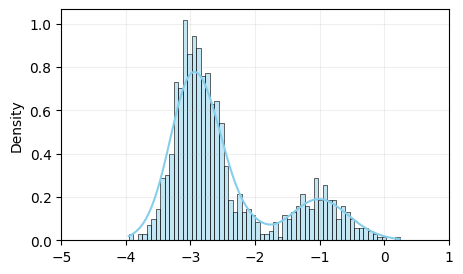

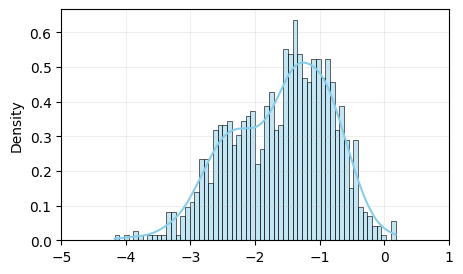

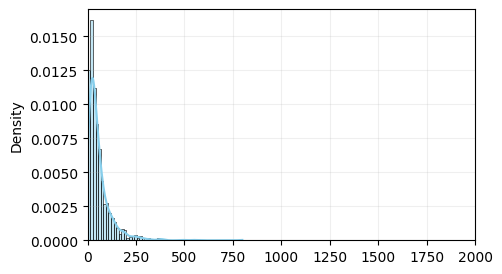

In [10]:
def visualize_samples(samples, figname, clip=[0, 1], logit_space=False):
    plt.figure(figsize=(5, 3))

    if logit_space:
        samples = logit(samples)
    sns.histplot(samples, bins=60, kde=True, stat="density", color='skyblue')

    plt.xlim(clip)

    plt.savefig(figname, format="pdf", bbox_inches="tight")
    plt.grid(alpha=0.2)
    plt.show()

ctr_data, _, cvr_data, _, wp = sample_campaign(
    seed = 1,
    sigma_ctr=1e-1,
    sigma_cvr=1e-1,
)

visualize_samples(ctr_data, f"figs/env/ctr_{len(ctr_data)}samples.pdf", clip=[-5, 1])
visualize_samples(cvr_data, f"figs/env/cvr_{len(cvr_data)}samples.pdf", clip=[-5, 1])
visualize_samples(wp, f"figs/env/wp_{len(wp)}samples.pdf", clip=[0, 2_000])

In [11]:
from experiment.non_robust_bid.offline_bidder import non_robust_bid
# from experiment.denoise_bid.ctr_only.offline_bidder import denoise_bid as ctr_only_denoise_bid
from experiment.denoise_bid.joint.offline_bidder import denoise_bid as joint_denoise_bid
from experiment.robust_bid.offline_bidder import robust_bid

from experiment.non_robust_bid.lp import solve_dual as non_robust_dual
from experiment.non_robust_bid.bid import bids as non_robust_bids

from experiment.utils.utils import logit, sigmoid

## Metrics calculation on clean environment

In [12]:
def simulate_offline_metrics(ctr_clean, cvr_clean, bids, wp, budget, target_cpc):
    is_win = bids >= wp
    total_conversions = float(np.sum(ctr_clean * cvr_clean * is_win))

    total_avg_cpc = wp.sum() / ctr_clean.sum()

    p, q = non_robust_dual(ctr_clean, cvr_clean, wp, budget, target_cpc)
    opt_bids = non_robust_bids(ctr_clean, cvr_clean, p, q, target_cpc)
    opt_value = ((opt_bids > wp) * ctr_clean * cvr_clean).sum()
    value_ratio = total_conversions / opt_value

    total_cost = float(np.sum(wp * is_win))
    total_clicks = float(np.sum(ctr_clean * is_win))
    avg_cpc = total_cost / total_clicks if total_clicks > 0 else 0.0

    avg_cpc_ratio = avg_cpc / total_avg_cpc

    return {
        "total_conversions": value_ratio,
        "avg_cpc": avg_cpc_ratio,
    }

## Experiment function

In [13]:
def run_single_experiment(
    seed: int,
    sigma_ctr: float,
    sigma_cvr: float,
    budget_proportion: float,
    target_cpc_proportion: float,
    bidder_mode: Literal["non-robust", "robust", "denoise"] = "non-robust",
    n_components = None,
):
    ctr_clean_logit, ctr_noised_logit, cvr_clean_logit, cvr_noised_logit, wp = sample_campaign(seed, sigma_ctr, sigma_cvr)

    ctr_clean = sigmoid(ctr_clean_logit)
    cvr_clean = sigmoid(cvr_clean_logit)
    ctr_noised = sigmoid(ctr_noised_logit)
    cvr_noised = sigmoid(cvr_noised_logit)

    budget = budget_proportion * wp.sum()
    target_cpc = target_cpc_proportion * wp.sum() / ctr_clean.sum()

    if bidder_mode == "non-robust":
        bids = non_robust_bid(ctr_noised_logit, cvr_noised_logit, wp, budget, target_cpc)
        metrics = simulate_offline_metrics(
            ctr_clean, cvr_clean, bids, wp, budget, target_cpc
        )

    elif bidder_mode == "robust":
        rob_eps = np.sum((ctr_noised - ctr_clean)**2) / 2
        bids = robust_bid(
            ctr_noised_logit,
            cvr_noised_logit,
            sigma_ctr,
            sigma_cvr,
            wp,
            budget,
            target_cpc,
            epsilon=rob_eps,
        )

        metrics = simulate_offline_metrics(
            ctr_clean, cvr_clean, bids, wp, budget, target_cpc,
        )

    elif bidder_mode == "denoise":
        bids = joint_denoise_bid(
            ctr_noised_logit,
            cvr_noised_logit,
            np.ones_like(ctr_noised_logit) * sigma_ctr,
            np.ones_like(cvr_noised_logit) * sigma_cvr,
            wp,
            budget,
            target_cpc,
            n_components=n_components,
        )

        metrics = simulate_offline_metrics(
            ctr_clean, cvr_clean, bids, wp, budget, target_cpc,
        )

    return {
        "sigma_ctr": sigma_ctr,
        "sigma_cvr": sigma_cvr,
        "seed": seed,
        "metrics": metrics,
    }

### Experiment aggregating function

In [14]:
def aggregate_results(raw_path: str, summary_path: str):
    df = pd.read_csv(raw_path)
    grouped = (
        df.groupby(["sigma_ctr", "sigma_cvr"])
        .agg(
            total_conversions_mean=("conversions", "mean"),
            total_conversions_std=("conversions", "std"),
            avg_cpc_mean=("cpc", "mean"),
            avg_cpc_std=("cpc", "std"),
        )
        .reset_index()
    )
    grouped.to_csv(summary_path, index=False)
    return summary_path

# ALL ALGORITHMS COMPARISON

In [15]:
SIGMAS_CTR = np.logspace(-2, 1, 10)
SIGMAS_CVR = np.logspace(-2, 1, 10)

SIGMA_GRID = [(s_ctr, s_cvr) for s_ctr in SIGMAS_CTR for s_cvr in SIGMAS_CVR]
NUM_SEEDS = 20

SEEDS = np.random.randint(0, 1_000_000_000, NUM_SEEDS)
BUDGET_PROPORTION = 0.2
TARGET_CPC_PROPORTION = 0.2

In [16]:
rows_non_robust = []
rows_robust = []
rows_normal = []
rows_2_comp = []

for sigma_ctr, sigma_cvr in tqdm(SIGMA_GRID):
    for seed in SEEDS:
        try:
            exp_res_nr = run_single_experiment(seed, sigma_ctr, sigma_cvr, BUDGET_PROPORTION, TARGET_CPC_PROPORTION, bidder_mode="non-robust")
            exp_res_rb = run_single_experiment(seed, sigma_ctr, sigma_cvr, BUDGET_PROPORTION, TARGET_CPC_PROPORTION, bidder_mode="robust")
            exp_res_norm = run_single_experiment(seed, sigma_ctr, sigma_cvr, BUDGET_PROPORTION, TARGET_CPC_PROPORTION, bidder_mode="denoise", n_components=1)
            exp_res_gm2 = run_single_experiment(seed, sigma_ctr, sigma_cvr, BUDGET_PROPORTION, TARGET_CPC_PROPORTION, bidder_mode="denoise", n_components=2)


            rows_normal.append(
                {
                    "sigma_ctr": sigma_ctr,
                    "sigma_cvr": sigma_cvr,
                    "SEED": seed,
                    "conversions": exp_res_norm["metrics"]["total_conversions"],
                    "cpc": exp_res_norm["metrics"]["avg_cpc"],
                }
            )

            rows_2_comp.append(
                {
                    "sigma_ctr": sigma_ctr,
                    "sigma_cvr": sigma_cvr,
                    "SEED": seed,
                    "conversions": exp_res_gm2["metrics"]["total_conversions"],
                    "cpc": exp_res_gm2["metrics"]["avg_cpc"],
                }
            )

            rows_non_robust.append(
                {
                    "sigma_ctr": sigma_ctr,
                    "sigma_cvr": sigma_cvr,
                    "SEED": seed,
                    "conversions": exp_res_nr["metrics"]["total_conversions"],
                    "cpc": exp_res_nr["metrics"]["avg_cpc"],
                }
            )

            rows_robust.append(
                {
                    "sigma_ctr": sigma_ctr,
                    "sigma_cvr": sigma_cvr,
                    "SEED": seed,
                    "conversions": exp_res_rb["metrics"]["total_conversions"],
                    "cpc": exp_res_rb["metrics"]["avg_cpc"],
                }
            )
        except Exception as e:
            print(f"Error in seed {seed}, sigma {sigma_ctr}, {sigma_cvr}: {e}")
            continue


df_non_robust = pd.DataFrame(rows_non_robust)
df_robust = pd.DataFrame(rows_robust)
df_normal = pd.DataFrame(rows_normal)
df_2_comp = pd.DataFrame(rows_2_comp)

non_robust_all_path = f"logs/joint/nr_c{TARGET_CPC_PROPORTION}_b{BUDGET_PROPORTION}.csv"
robust_all_path = f"logs/joint/rb_c{TARGET_CPC_PROPORTION}_b{BUDGET_PROPORTION}.csv"
normal_all_path = f"logs/joint/norm_c{TARGET_CPC_PROPORTION}_b{BUDGET_PROPORTION}.csv"
gm_2_comp_all_path = f"logs/joint/gm2_c{TARGET_CPC_PROPORTION}_b{BUDGET_PROPORTION}.csv"

df_non_robust.to_csv(non_robust_all_path, index=False)
df_robust.to_csv(robust_all_path, index=False)
df_normal.to_csv(normal_all_path, index=False)
df_2_comp.to_csv(gm_2_comp_all_path, index=False)

100%|██████████| 100/100 [1:29:28<00:00, 53.69s/it]


In [17]:
non_robust_summary_path = f"logs/joint/nr_c{TARGET_CPC_PROPORTION}_b{BUDGET_PROPORTION}_summary.csv"
robust_summary_path = f"logs/joint/rb_c{TARGET_CPC_PROPORTION}_b{BUDGET_PROPORTION}_summary.csv"
normal_summary_path = f"logs/joint/norm_c{TARGET_CPC_PROPORTION}_b{BUDGET_PROPORTION}_summary.csv"
gm_2_comp_summary_path = f"logs/joint/gm2_c{TARGET_CPC_PROPORTION}_b{BUDGET_PROPORTION}_summary.csv"

aggregate_results(non_robust_all_path, non_robust_summary_path)
aggregate_results(robust_all_path, robust_summary_path)
aggregate_results(normal_all_path, normal_summary_path)
aggregate_results(gm_2_comp_all_path, gm_2_comp_summary_path)

'logs/joint/gm2_c0.2_b0.2_summary.csv'

### *FIGURE*

In [18]:
df_list_names = [
    f"logs/joint/nr_c{TARGET_CPC_PROPORTION}_b{BUDGET_PROPORTION}_summary.csv",
    f"logs/joint/rb_c{TARGET_CPC_PROPORTION}_b{BUDGET_PROPORTION}_summary.csv",
    f"logs/joint/norm_c{TARGET_CPC_PROPORTION}_b{BUDGET_PROPORTION}_summary.csv",
    f"logs/joint/gm2_c{TARGET_CPC_PROPORTION}_b{BUDGET_PROPORTION}_summary.csv",
]

exp_num = len(df_list_names)

name_fig = f"figs/exp/joint/b{BUDGET_PROPORTION}_c{TARGET_CPC_PROPORTION}.pdf"
c_arr = ["NonRobustBid", "RobustBid", "DenoiseBid (normal prior)", "DenoiseBid (2-comp prior)"]

In [19]:
metrics = [
    {
        "name": "total_conversions",
        "title": "",
        "ylabel": "$\\frac{R}{R*}$",
    },
    {
        "name": "avg_cpc",
        "title": "",
        "ylabel": "$\\frac{avg\\_CPC}{mean\\_campaign\\_CPC}$",
    },
]

dfs = []
for name in df_list_names:
    dfs.append(pd.read_csv(name))

In [20]:
colors = plt.cm.tab20(np.linspace(0, 1, len(dfs)))

In [21]:
from scipy.ndimage import gaussian_filter

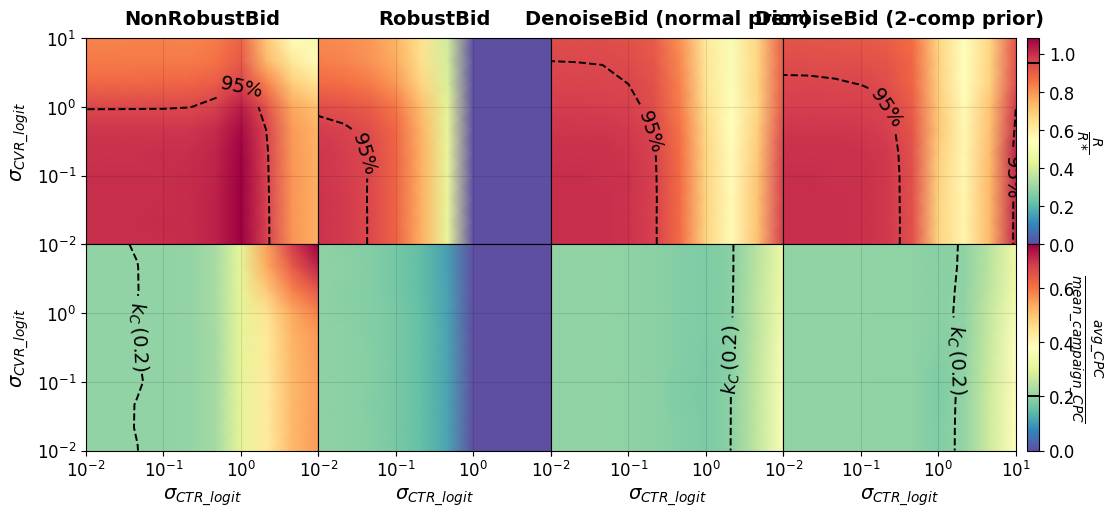

In [22]:
metric_limits = []
for metric in metrics:
    col_name = f"{metric['name']}_mean"
    all_values = np.concatenate([df[col_name].values for df in dfs])
    g_min = np.nanmin(all_values)
    g_max = np.nanmax(all_values)
    metric_limits.append((g_min, g_max))

n_metrics = len(metrics)
n_bidders = len(dfs)

fig, axes = plt.subplots(
    nrows=n_metrics,
    ncols=n_bidders,
    figsize=(12, 5.5),
    sharex=True, 
    sharey=True,
)

axes = np.atleast_2d(axes)
if axes.shape != (n_metrics, n_bidders):
    axes = axes.reshape(n_metrics, n_bidders)

plt.subplots_adjust(wspace=0, hspace=0, top=0.85, bottom=0.1)

for j, metric in enumerate(metrics):
    vmin, vmax = metric_limits[j]

    for i, df in enumerate(dfs):
        ax = axes[j, i]
        
        pivot = df.pivot(
            index="sigma_cvr",
            columns="sigma_ctr",
            values=f"{metric['name']}_mean"
        ).sort_index(ascending=True).sort_index(axis=1, ascending=True)

        X_vals = pivot.columns.values
        Y_vals = pivot.index.values
        Z = pivot.values
        X_grid, Y_grid = np.meshgrid(X_vals, Y_vals)

        im = ax.pcolormesh(
            X_grid, Y_grid, Z,
            shading='gouraud',
            cmap="Spectral_r",
            vmin=vmin, vmax=vmax
        )

        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.minorticks_off()
        ax.grid(True, which="major", linestyle="-", alpha=0.1, color='black')

        if j == 0:
            ax.set_title(c_arr[i], fontsize=14, fontweight='bold', pad=10)
        
        if i == 0:
            ax.tick_params(labelsize=12)
            ax.set_ylabel("$\\sigma_{CVR\\_logit}$", fontsize=14)
            
        if j == n_metrics - 1:
            ax.tick_params(labelsize=12)
            ax.set_xlabel("$\\sigma_{CTR\\_logit}$", fontsize=14)

        if i == n_bidders - 1:
            cax = ax.inset_axes([1.05, 0.0, 0.05, 1.0])
            cbar = fig.colorbar(im, cax=cax, orientation='vertical')
            cbar.ax.tick_params(labelsize=12)
            cbar.set_label(metric["ylabel"], fontsize=14, fontweight='bold', rotation=270, labelpad=20)

        if metric["name"] == "total_conversions":
            Z_smoothed = gaussian_filter(Z, sigma=0.5)
            cs = ax.contour(
                X_grid, Y_grid, Z_smoothed,
                levels=[0.95],
                colors="black",
                linewidths=1.4,
                alpha=1,
                linestyles='dashed',
            )
            ax.clabel(cs, inline=True, fontsize=14, fmt={0.95: '$95\\%$'})
            if i == n_bidders - 1:
                cbar.ax.axhline(
                    0.95,
                    color='black',
                    linewidth=1.4,
                    alpha=1
                )

        if metric["name"] == "avg_cpc":
            Z_smoothed = gaussian_filter(Z, sigma=0.55)
            cs = ax.contour(
                X_grid, Y_grid, Z_smoothed,
                levels=[TARGET_CPC_PROPORTION],
                colors="black", linewidths=1.4,
                alpha=1,
                linestyles='dashed',
            )
            lbs = ax.clabel(cs, inline=True, fontsize=14, fmt={TARGET_CPC_PROPORTION: f'$k_C\\,(0.2)$'})
            if i == n_bidders - 1:
                cbar.ax.axhline(
                    TARGET_CPC_PROPORTION,
                    color='black',
                    linewidth=1.4,
                    alpha=1
                )

fig.canvas.draw() 

for j in range(n_metrics):
    for i in range(n_bidders):
        ax = axes[j, i]
        
        if i > 0:
            ax.tick_params(axis='y', which='both', left=False, right=False, labelleft=False)
            for label in ax.get_yticklabels():
                label.set_visible(False)
            
            ax.yaxis.get_offset_text().set_visible(False)

        if j < n_metrics - 1:
            ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
            for label in ax.get_xticklabels():
                label.set_visible(False)
            ax.xaxis.get_offset_text().set_visible(False)

        if j == n_metrics - 1 and i < n_bidders - 1:
            xmax = ax.get_xlim()[1]
            for label in ax.get_xticklabels():
                if not label.get_visible(): continue
                pos = label.get_position()[0]
                if np.isclose(pos, xmax, rtol=1e-1):
                    label.set_visible(False)

        if i == 0 and j > 0:
            ymax = ax.get_ylim()[1]
            for label in ax.get_yticklabels():
                if not label.get_visible(): continue
                pos = label.get_position()[1]
                if np.isclose(pos, ymax, rtol=1e-1):
                    label.set_visible(False)

plt.savefig(name_fig, format="pdf", bbox_inches="tight")
plt.show()